# The Colonial Origins of Comparative Development (Acemoglu, Johnson, & Robinson, 2001)

This notebook reproduces the main empirical findings of Acemoglu, Johnson, and Robinson's (2001) highly influential paper on the long-term socio-economic impacts of historical institutions.

### Setup and Data Ingestion
We begin by importing our analytical libraries and defining a helper function to extract variable labels directly from the original `.dta` file, ensuring our data dictionary remains intact and interpretable.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from linearmodels.iv import IV2SLS, compare
from IPython.display import display, HTML

In [123]:
def get_labels(data):
    stata_reader = pd.read_stata(data, iterator=True)
    labels_dict = stata_reader.variable_labels()
    data_dictionary = pd.DataFrame(columns=["Variable", "Label"], data=list(labels_dict.items()))
    return data_dictionary

In [124]:
df = pd.read_stata("../Data/Acemoglu/AJR_dataset.dta")
df_labels = get_labels("../Data/Acemoglu/AJR_dataset.dta")

## 1. The Reduced-Form Relationship: Income and Settler Mortality

First, we look at the basic relationship between historical data and current results before modeling how institutions formed.

This code replicates **Figure 1** from the paper. It plots the connection between early European settler mortality rates and today's economic performance, measured as Log GDP per capita. There's a clear negative correlation, areas with higher historical settler mortality tend to have much lower economic development.

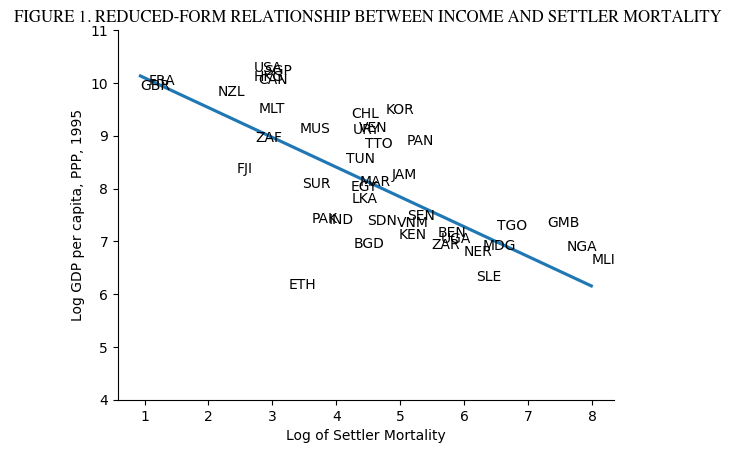

In [125]:
sns.regplot(data=df, x="logem4", y="logpgp95",ci=None, scatter=False)
sns.despine()
plt.title(" FIGURE 1. REDUCED-FORM RELATIONSHIP BETWEEN INCOME AND SETTLER MORTALITY", fontname="Times", )
plt.xlabel("Log of Settler Mortality")
plt.ylabel("Log GDP per capita, PPP, 1995")
plt.ylim(4,11)

for mort, gdp in dict(zip(df["logem4"], df["logpgp95"])).items():
    country = df.loc[(df["logpgp95"] == gdp) & (df["logem4"] == mort), "shortnam"]
    plt.text(s=str(country)[7:10],
             x=mort, y=gdp)
    
plt.show()

## 2. Baseline OLS Estimates (Table 2)

We start the regression analysis by estimating the Ordinary Least Squares (OLS) relationship between current institutions, measured by the "Average protection against expropriation risk," and economic performance. We look at both the global sample and the base ex-colony sample. 

To check how solid this association is, we add control variables like latitude and continent dummies one step at a time. Stargazer then presents the results in a clean format.

In [126]:
controls = ["lat_abst", "asia", "africa", "other_cont"]
regressors = ["avexpr"] + controls

reg1 = smf.ols(formula = "logpgp95 ~ avexpr", data=df).fit()
reg2 = smf.ols(formula = "logpgp95 ~ avexpr", data=df.query("baseco==1")).fit()

reg3 = smf.ols(formula = "logpgp95 ~ avexpr + lat_abst", data=df).fit()
reg4 = smf.ols(formula=f"logpgp95 ~ avexpr + {'+'.join(controls)}", data=df).fit()

reg5 = smf.ols(formula = "logpgp95 ~ avexpr + lat_abst", data=df.query("baseco==1")).fit()
reg6 = smf.ols(formula=f"logpgp95 ~ avexpr + {'+'.join(controls)}", data=df.query("baseco==1")).fit()

reg7 = smf.ols(formula = "loghjypl ~ avexpr", data=df).fit()
reg8 = smf.ols(formula = "loghjypl ~ avexpr", data=df.query("baseco==1")).fit()

models=[reg1, reg2, reg3, reg4, reg5, reg6, reg7, reg8]

In [127]:
table2 = Stargazer(models)
cov_labels = ["Average protection against expropriation risk, 1985-1995",
              "Latitude", "Asia dummy", "Africa dummy", "Other continent dummy"]
table2.covariate_order(regressors)
table2.rename_covariates(dict(zip(regressors, cov_labels)))
table2.custom_columns(["Whole world (1)", "Base sample (2)", "Whole world (3)","Whole world (4)", "Base sample (5)", "Base sample (6)", "Whole world (7)", "Base sample (8)"])
table2.show_model_numbers(False)
table2.dep_var_name = "Dependent Variable: Log GDP per capita (1-6) /   Log output per worker in 1998 (7-8)"
table2.covariate_order(regressors)
table2.show_adj_r2 = False
table2.show_confidence_intervals(False)
table2.show_degrees_of_freedom(False)
table2.show_f_statistic = False
table2.show_residual_std_err = False
table2

## 3. The Instrumental Variable (IV) Approach

While the OLS results show a strong positive correlation between secure property rights and GDP per capita, these estimates are likely biased due to reverse causality (richer countries can afford better institutions) and omitted variables. 

To isolate the causal impact of institutions on inequality and development, the authors propose an Instrumental Variable (IV) approach. The core premise is:
1. **Mortality affected settlements:** High mortality deterred European settlement.
2. **Settlements affected early institutions:** Where Europeans settled, they built inclusive institutions; where they could not, they set up extractive states.
3. **Early institutions persist:** Those extractive or inclusive structures have largely survived into the present day.

Therefore, we can use **historical settler mortality as an instrument for current institutional quality**. Below, we prepare the specific sample cuts (e.g., excluding Neo-Europes or Africa) required for the replication of **Table 4**.

In [128]:
base_sample = df.query("baseco == 1")
bs_without_neo_europes = base_sample.query("rich4 == 0")
bs_without_africa = base_sample.query("africa == 0")
samples = [base_sample, bs_without_neo_europes, bs_without_africa]

### 3.1 OLS regression

In [129]:
regressors =  [["avexpr"], ["avexpr", "lat_abst"]]
with_continents = [["avexpr","asia", "africa","other_cont" ],
                   ["avexpr", "lat_abst","asia", "africa","other_cont"]] 

ols_models = []

for sample in samples:
    for indep in regressors:
        reg = smf.ols(formula=f"logpgp95 ~ {'+'.join(indep)}", data=sample).fit()
        ols_models.append(reg)
        
for indep in with_continents:
    reg = smf.ols(formula=f"logpgp95 ~ {'+'.join(indep)}", data=base_sample).fit()
    ols_models.append(reg)

reg_worker = smf.ols(formula="loghjypl ~ avexpr", data=base_sample).fit()
ols_models.append(reg_worker)

table4_ols = Stargazer(ols_models)
table4_ols.covariate_order(["avexpr"])
table4_ols.show_adj_r2 = False
table4_ols.show_confidence_intervals(False)
table4_ols.show_degrees_of_freedom(False)
table4_ols.show_f_statistic = False
table4_ols.show_residual_std_err = False
table4_ols.custom_columns(["Base Sample", "Base Sample", "Base sample without Neo-Europes","Base sample without Neo-Europes", "Base sample without Africa", "Base sample without Africa", "Base sample with continent dummies", "Base sample with continent dummies", "Base sample, dependet variable is log output per worker"])
table4_ols.show_r2 = False
table4_ols.show_notes = False
table4_ols.dep_var_name = "Log GDP per Capita"

table4_ols

### 3.2 First Stage: Instrument Relevance

A valid instrumental variable must be strongly correlated with the endogenous explanatory variable. In this First Stage analysis, we regress our endogenous variable (Protection against Expropriation Risk) on our instrument (Log Settler Mortality) across the different sample specifications to confirm its predictive power.

In [130]:
regressors =  [["logem4"], ["logem4", "lat_abst"]]
with_continents = [["logem4","asia", "africa","other_cont" ],
                   ["logem4", "lat_abst","asia", "africa","other_cont"]] 

fs_models = []

for sample in samples:
    for indep in regressors:
        reg = smf.ols(formula=f"avexpr ~ {'+'.join(indep)}", data=sample).fit()
        fs_models.append(reg)
        
for indep in with_continents:
    reg = smf.ols(formula=f"avexpr ~ {'+'.join(indep)}", data=base_sample).fit()
    fs_models.append(reg)

reg_worker = smf.ols(formula="loghjypl ~ logem4", data=base_sample).fit()
fs_models.append(reg_worker)

table4_fs = Stargazer(fs_models)
table4_fs.covariate_order(with_continents[1])
table4_fs.show_adj_r2 = False
table4_fs.show_confidence_intervals(False)
table4_fs.show_degrees_of_freedom(False)
table4_fs.show_f_statistic = False
table4_fs.show_residual_std_err = False
table4_fs.custom_columns(["Base Sample", "Base Sample", "Base sample without Neo-Europes","Base sample without Neo-Europes", "Base sample without Africa", "Base sample without Africa", "Base sample with continent dummies", "Base sample with continent dummies", "Base sample, dependet variable is log output per worker"])
table4_fs.dep_var_name = "Log GDP per Capita"
table4_fs.title("First Stage for Average Protection Against Expropriation Risk in 1985-1995")

table4_fs

### 3.2 Second Stage: IV-2SLS Estimation

Finally, we estimate the causal effect of institutions on economic performance using Two-Stage Least Squares (IV-2SLS). By instrumenting modern property rights with historical mortality rates, we strip away the endogeneity bias. 

We rely on the `linearmodels` library to execute the 2SLS regressions with robust standard errors, reproducing the definitive findings of Table 4.

In [131]:
with_continents = [["asia", "africa","other_cont" ],
                   ["lat_abst","asia", "africa","other_cont"]] 

iv_models = []

iv_columns = ["Base Sample (1)", "Base Sample (2)", "Base Sample without Neo-Europes (3)" ,
             "Base Sample without Neo-Europes (4)", "Base Sample without Neo-Africa (5)",
            "Base Sample without Neo-Africa (6)", "Base sample with continent dummies (7)", 
            "Base sample with continent dummies (8)", "Base sample, dependent variable is log output per worker (8)"]


for sample in samples:
    reg1 = IV2SLS.from_formula(formula=f"logpgp95 ~ 1 + [avexpr ~ logem4]", data=sample).fit()
    iv_models.append(reg1)
    reg2 = IV2SLS.from_formula(formula=f"logpgp95 ~ 1 + [avexpr ~ logem4] + lat_abst", data=sample).fit()
    iv_models.append(reg2) 
    

for indep in with_continents:
    reg = IV2SLS.from_formula(formula=f"logpgp95 ~ 1 + [avexpr ~ logem4] + {'+'.join(indep)}", data=base_sample).fit()
    iv_models.append(reg)

reg_worker = IV2SLS.from_formula(formula="loghjypl ~ 1 + [avexpr ~ logem4]", data=base_sample.dropna(subset="loghjypl")).fit()
iv_models.append(reg_worker)


full = dict(zip(iv_columns, iv_models))
tab = compare(full, stars=True, precision="std_errors")
display(HTML(tab.summary.as_html()))

,Base Sample (1),Base Sample (2),Base Sample without Neo-Europes (3),Base Sample without Neo-Europes (4),Base Sample without Neo-Africa (5),Base Sample without Neo-Africa (6),Base sample with continent dummies (7),Base sample with continent dummies (8),"Base sample, dependent variable is log output per worker (8)"
Dep. Variable,logpgp95,logpgp95,logpgp95,logpgp95,logpgp95,logpgp95,logpgp95,logpgp95,loghjypl
Estimator,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS,IV-2SLS
No. Observations,64,64,60,60,37,37,64,64,61
Cov. Est.,robust,robust,robust,robust,robust,robust,robust,robust,robust
R-squared,0.1870,0.1025,-0.6877,-0.4918,0.5874,0.5886,0.2286,0.0108,-0.1518
Adj. R-squared,0.1739,0.0730,-0.7168,-0.5442,0.5756,0.5644,0.1763,-0.0745,-0.1714
F-statistic,28.754,28.333,10.163,13.536,49.934,50.806,36.376,28.443,24.958
P-value (F-stat),8.217e-08,7.041e-07,0.0014,0.0011,1.59e-12,9.282e-12,2.421e-07,2.981e-05,5.86e-07
==================,===========,===========,===========,===========,===========,===========,===========,===========,============
Intercept,1.9097,1.6918,-0.1412,0.1442,4.5539***,4.5623***,2.0324,1.4405,-8.3229***
